In [151]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent.parent.parent))

from test.lib.files_utils import SimulationOutput, LisLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps, rcParams
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit

rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
    'pgf.preamble': '',
    "font.family": "serif",
    "font.serif": ["times"],
    "axes.unicode_minus": False
})
plt.rc('xtick', top=True, bottom=True, labelsize=30, direction='in')
plt.rc('ytick', left=True, right=True, labelsize=30, direction='in')
plt.rc('xtick.major', size=16, pad=12, width=2.5)
plt.rc('ytick.major', size=16, pad=12, width=2.5)
plt.rc('xtick.minor', size=8, width=1.5)
plt.rc('ytick.minor', size=8, width=1.5)
plt.rc('axes', titlesize=35, labelsize=30, titleweight='bold', titlepad=20, linewidth=1, edgecolor='k')
plt.rc('figure', titlesize=35)
plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [152]:
def set_axis_fine_grid(ax, axis='both'):
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='grey', axis=axis)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='darkgrey', axis=axis)


def make_pair_panel(shape=(1, 2), sharey=True, figsize=(18, 7.5)):
    fig, axs = plt.subplots(*shape, figsize=figsize, tight_layout=True, sharey=sharey)
    for ax in axs.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
        set_axis_fine_grid(ax)
    return fig, *axs.flatten()


def reorder_list(lst, order):
    assert len(lst) == len(order)
    return [lst[i] for i in order]


def get_ax_legend_handles_labels(ax):
    return ax.legend_.legend_handles, [t.get_text() for t in ax.legend_.get_texts()]


def make_figure_legend(fig, axs, title, map_handles=None, map_labels=None, reorder=None, extra_kwargs=None):
    if extra_kwargs is None:
        extra_kwargs = {}

    ax1_handles, ax1_labels = get_ax_legend_handles_labels(axs[0])
    for ax in axs[1:]:
        assert len(ax1_handles) == len(get_ax_legend_handles_labels(ax)[0]) and len(ax1_labels) == len(
            get_ax_legend_handles_labels(ax)[1])

    nrows = 2 if len(ax1_handles) > 6 else 1
    ncols = int(np.ceil(len(ax1_handles) / nrows))

    if map_handles is not None:
        ax1_handles = list(map(map_handles, ax1_handles))
    if map_labels is not None:
        ax1_labels = list(map(map_labels, ax1_labels))
    if reorder is not None:
        ax1_handles = reorder_list(ax1_handles, reorder)
        ax1_labels = reorder_list(ax1_labels, reorder)

    leg = fig.legend(
        **dict(
            handles=ax1_handles,
            labels=ax1_labels,
            title=title,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.21 if nrows > 1 else -0.16),
            ncol=ncols,
            handlelength=2,
            markerscale=2,
        ) | extra_kwargs,
    )
    for line in leg.get_lines():
        line.set_linewidth(3)

    for ax in axs:
        ax.legend_.remove()

    return leg


def format_int_to_date(date):
    date = str(date)
    return f'{date[:4]}-{date[4:6]}-{date[6:]}'


def format_int_to_cr(date):
    return int({
                   20111116: 2117,
                   20140917: 2155,
                   20150907: 2168,
                   20160827: 2181,
                   20170623: 2192,
                   20180929: 2209,
               }[int(date)])


def iso_name_map(name):
    return str({
                   'Proton': 'proton',
                   'Deuterium': 'deuteron',
               }[str(name)])


def save_plot(name):
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(Path().resolve().parent / 'data' / 'publications' / f'{name}.png', bbox_inches='tight', pad_inches=0.1)

In [153]:
from pathlib import Path

data_dir = Path().resolve().parent / 'data'

lis_loader = LisLoader(data_dir / 'LIS_Default2020_Proton')

isotopes = ['Proton', 'Deuterium']

particles_df = []
fluxes_df = []

for period in Path(data_dir / 'runned_tests_rigidity').glob('*/outfile/'):
    outputs = dict()
    cr = format_int_to_cr(period.parts[-2].split('_')[-1])
    for isotope in isotopes:
        out = list(period.glob(f'{isotope}*.dat'))[0]
        outputs[iso_name_map(isotope)] = out.read_text()

        parts = list(period.glob(f'{isotope}*_prop_out.txt'))[0]

        init_rig = None
        for line in parts.read_text().splitlines():
            if line.startswith('# Generated initial rigidity = '):
                init_rig = float(line.split('=')[-1])
            elif not line.startswith('#'):
                particles_df.append(
                    [cr, iso_name_map(isotope), init_rig, *list(map(float, line.split()))]
                )

    modulated = SimulationOutput.from_txt([outputs]).modulate(lis_loader)[0]
    for rig, flux, l_flux in zip(modulated.rigidity, modulated.flux, modulated.lis):
        fluxes_df.append([cr, rig, flux, l_flux])

In [154]:
fluxes_df = pd.DataFrame(fluxes_df, columns=['cr', 'rig', 'flux', 'lis'])
fluxes_df

,cr,rig,flux,lis
0,2117,1.080000,813.368863,5193.395432
1,2117,1.245000,834.397834,4300.763130
2,2117,1.420000,816.332959,3503.962639
3,2117,1.610000,750.004909,2816.511341
4,2117,1.815000,683.761966,2244.914200
...,...,...,...,...
175,2192,19.700001,4.172416,4.805919
176,2192,28.150000,1.558810,1.724022
177,2192,41.000000,0.546836,0.586804
178,2192,59.099998,0.196458,0.206504


In [155]:
particles_df = pd.DataFrame(particles_df, columns=['cr', 'isotope', 'R_in', 'r', 'theta', 'phi', 'R_out', 't_fly',
                                                   *[f'zone_{i}' for i in range(15)], 'heliosheat'])
particles_df

,cr,isotope,R_in,r,theta,phi,R_out,t_fly,zone_0,zone_1,...,zone_6,zone_7,zone_8,zone_9,zone_10,zone_11,zone_12,zone_13,zone_14,heliosheat
0,2117,proton,1.080000,159.953339,2.130278,3.577904,1.595499,7.865374e+07,194776.921875,645850.000000,...,4.460000e+04,8.980000e+04,541800.0,531600.0,251950.000000,2.446500e+05,501300.000000,683850.000000,1.376400e+06,72579456.0
1,2117,proton,1.080000,168.479904,2.306070,5.959561,1.572972,1.987497e+07,296716.500000,265050.000000,...,2.625500e+05,3.492500e+05,373850.0,110600.0,81950.000000,1.189000e+05,44300.000000,93250.000000,5.830500e+05,16379200.0
2,2117,proton,1.080000,168.474304,2.206279,0.309218,1.636367,6.604193e+07,96218.921875,281900.000000,...,1.117150e+06,1.056700e+06,428500.0,269050.0,553600.000000,1.009150e+06,407800.000000,320250.000000,6.351000e+05,58330176.0
3,2117,proton,1.080000,168.473160,1.957281,1.291442,1.770271,2.274650e+07,201500.000000,322650.000000,...,9.999000e+05,1.376250e+06,1295800.0,799650.0,737150.000000,6.583500e+05,439300.000000,256550.000000,2.619500e+05,13797550.0
4,2117,proton,1.080000,167.752594,1.059111,1.729170,1.877435,2.145593e+07,646076.500000,280600.000000,...,2.808000e+05,2.192000e+05,637050.0,550650.0,257000.000000,5.415000e+04,86250.000000,155050.000000,1.524500e+05,16233050.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808635,2192,deuteron,84.849998,135.483994,0.674256,2.312547,85.370056,1.810430e+05,591.049133,908.246155,...,5.750000e+03,6.050000e+03,5900.0,4900.0,8300.000000,1.045000e+04,11008.330078,7691.096680,3.744230e+03,93850.0
1808636,2192,deuteron,84.849998,132.513351,1.007467,3.785666,85.487999,4.133502e+05,2262.377197,3087.806152,...,1.900000e+03,5.850000e+03,10250.0,7550.0,8550.000000,4.350000e+03,3100.000000,6600.000000,1.005000e+04,330550.0
1808637,2192,deuteron,84.849998,138.376495,2.893610,4.889444,85.533401,1.749069e+05,864.890320,3850.273926,...,8.950000e+03,7.500000e+03,4050.0,4700.0,7000.000000,4.500000e+03,4150.000000,4991.723145,7.800000e+03,82800.0
1808638,2192,deuteron,84.849998,138.364151,0.458351,5.610957,85.330666,1.454287e+05,234.270920,604.493530,...,1.275000e+04,1.187341e+04,8300.0,4550.0,2894.527832,3.297608e+03,2761.109131,3600.000000,3.950000e+03,67300.0


In [156]:
particles_df['cr'].unique(), particles_df['R_in'].unique()

(array([2117, 2209, 2168, 2181, 2155, 2192]),
 array([ 1.08    ,  1.245   ,  1.42    ,  1.61    ,  1.815   ,  2.035   ,
         2.275   ,  2.535   ,  2.82    ,  3.12999 ,  3.465   ,  3.83    ,
         4.225   ,  4.655   ,  5.125   ,  5.635   ,  6.185   ,  6.78    ,
         7.425   ,  8.12    ,  8.87    ,  9.68    , 10.55    , 12.      ,
        14.8     , 19.700001, 28.15    , 41.      , 59.099998, 84.849998]))

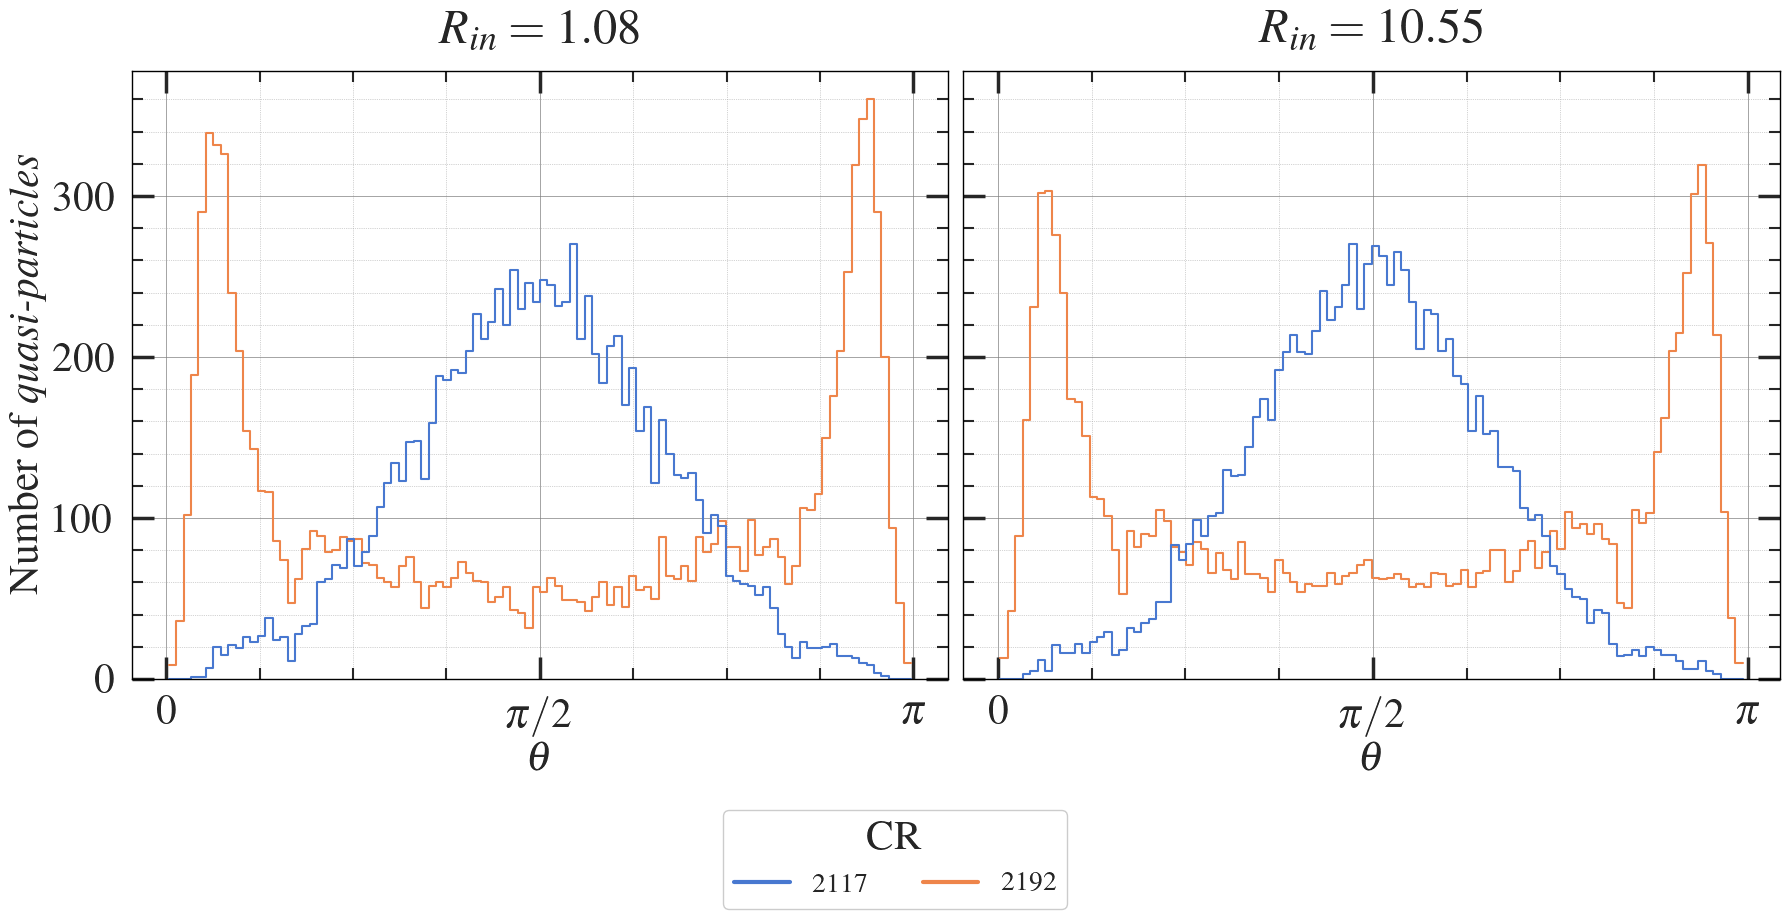

In [157]:
def plot_theta_vs_count(rigs, crs):
    rows = -(len(rigs) // -2)
    fig, axs = plt.subplots(rows, 2, tight_layout=True, figsize=(18, 8 * rows), sharey='row')
    axs = axs.flatten()
    for rig, ax in zip(rigs, axs):
        set_axis_fine_grid(ax)
        sns.histplot(
            particles_df.query(f'(cr in {crs}) & (R_in == {rig})'),
            x='theta',
            hue='cr',
            element='step',
            palette='muted',
            fill=False,
            bins=100,
            ax=ax,
        )
        # print(dir(ax.legend_))
        # print(ax.legend_.get_label())
        ax.set_xticks([0, np.pi / 2, np.pi], labels=[r'$0$', r'$\pi/2$', r'$\pi$'])
        ax.set(title=f'$R_{{in}} = {rig}$', xlabel=r'$\theta$', ylabel=r'Number of \textit{quasi-particles}')
    make_figure_legend(fig, axs, 'CR')


plot_theta_vs_count([1.08, 10.55], [2117, 2192])

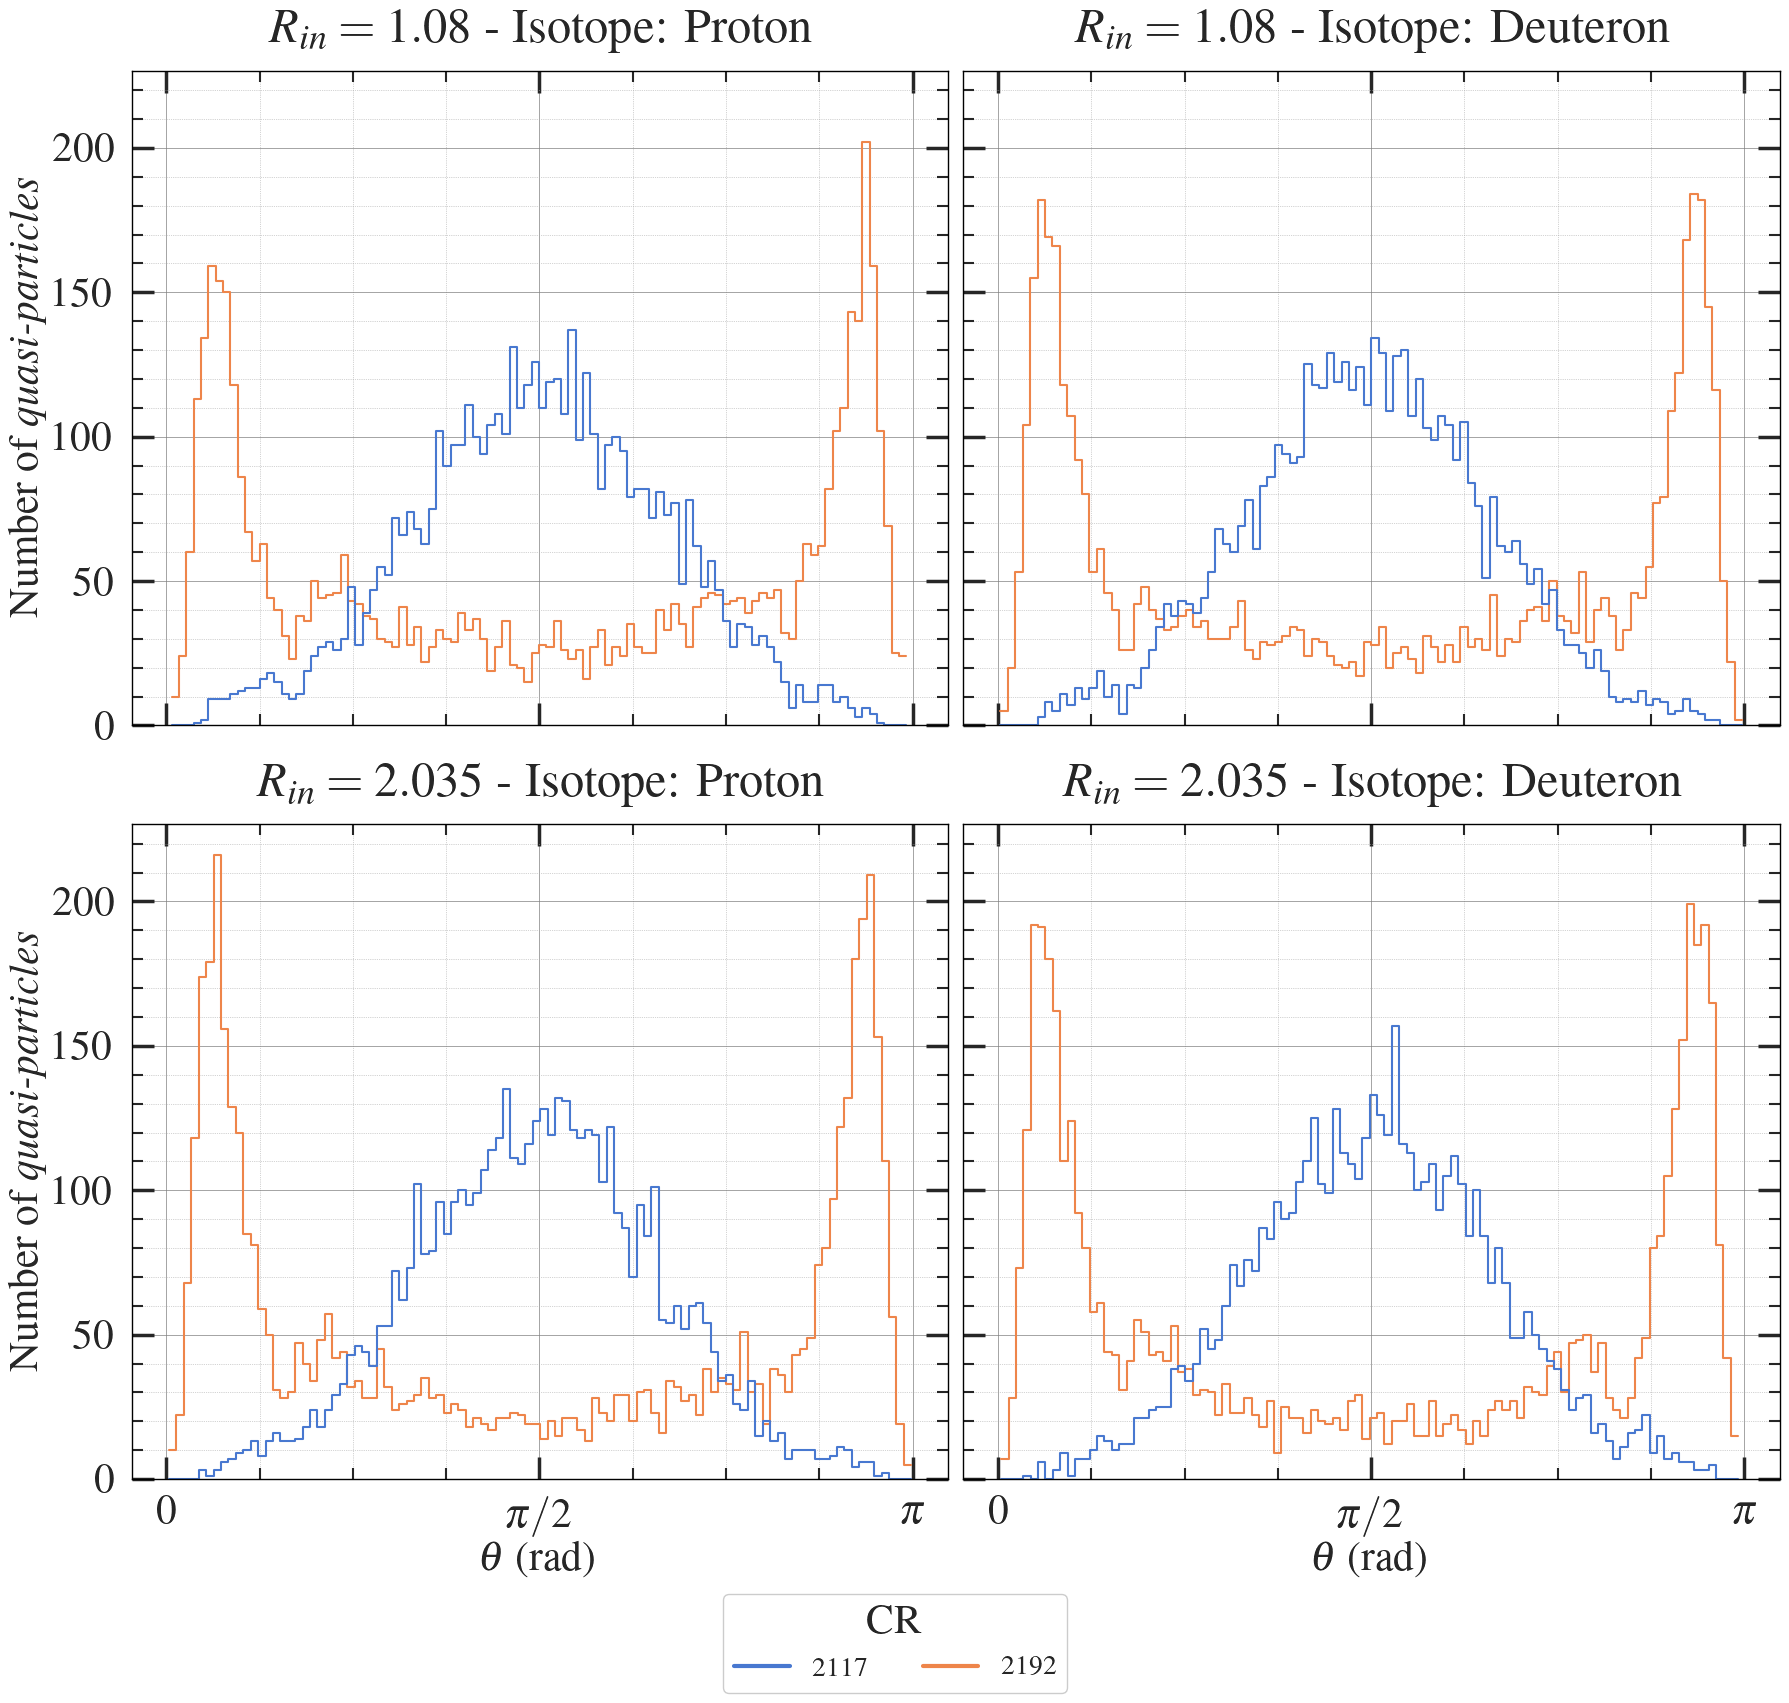

In [158]:
def plot_theta_vs_count(rigs, crs, isos=('proton', 'deuteron')):
    fig, axss = plt.subplots(len(rigs), 2, tight_layout=True, figsize=(18, 8 * len(rigs)), sharex=True, sharey=True)
    for rig, axs in zip(rigs, axss):
        for iso, ax in zip(isos, axs):
            set_axis_fine_grid(ax)
            sns.histplot(
                particles_df.query(f'(cr in {crs}) & (R_in == {rig}) & (isotope == "{iso}")'),
                x='theta',
                hue='cr',
                element='step',
                palette='muted',
                fill=False,
                bins=100,
                ax=ax,
            )
            ax.set_xticks([0, np.pi / 2, np.pi], labels=[r'$0$', r'$\pi/2$', r'$\pi$'])
            ax.set(title=f'$R_{{in}} = {rig}$  -  Isotope: {iso.title()}', xlabel=r'$\theta$ (rad)',
                   ylabel=r'Number of \textit{quasi-particles}')
    make_figure_legend(fig, axss.flatten(), 'CR', extra_kwargs=dict(bbox_to_anchor=(0.5, -0.07)))


plot_theta_vs_count([1.08, 2.035], [2117, 2192])

In [159]:
# df[list(df.filter(regex='Economics'))].sum(axis=1)
particles_df.filter(regex='zone_').sum(axis=1)

0          6.327377e+06
1          3.495766e+06
2          8.033069e+06
3          8.948950e+06
4          5.222876e+06
               ...     
1808635    8.719295e+04
1808636    8.280018e+04
1808637    9.210689e+04
1808638    7.812877e+04
1808639    5.522450e+04
Length: 1808640, dtype: float64

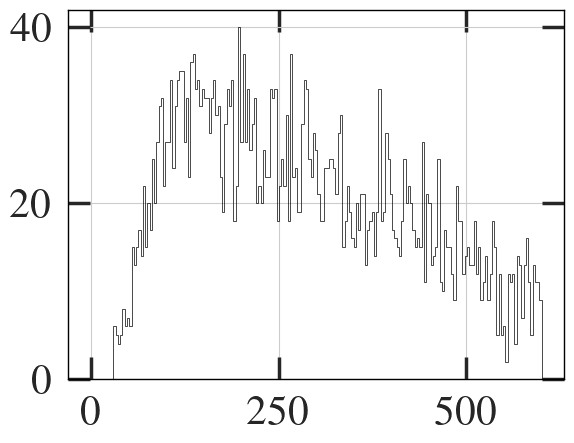

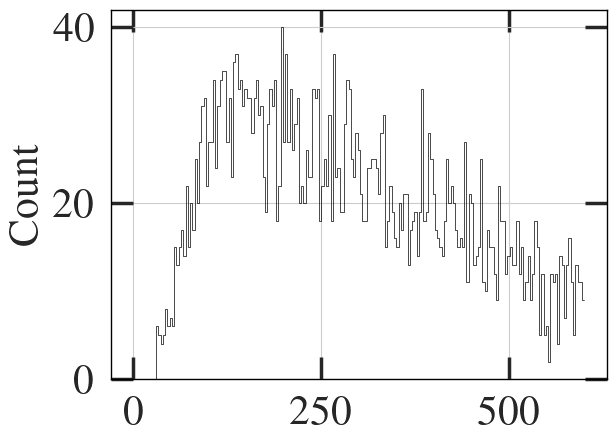

In [160]:
tmp = particles_df.query('(cr == 2117) & (isotope == "deuteron") & (R_in == 1.08)')['heliosheat'].to_numpy()
# print(list(tmp), tmp.mean(), len(tmp))
plt.hist(tmp / 86400, bins=np.linspace(0, 600, 200), histtype='step', color='k', linewidth=0.5)
plt.show()
# sns.histplot(x=tmp / 86400, bins=np.linspace(0, 600, 200), element='step', fill=False, linewidth=0.5, color='k')
sns.histplot(x=tmp / 86400, bins=200 - 1, binrange=(0, 600), element='step', fill=False, linewidth=0.5, color='k')
plt.show()

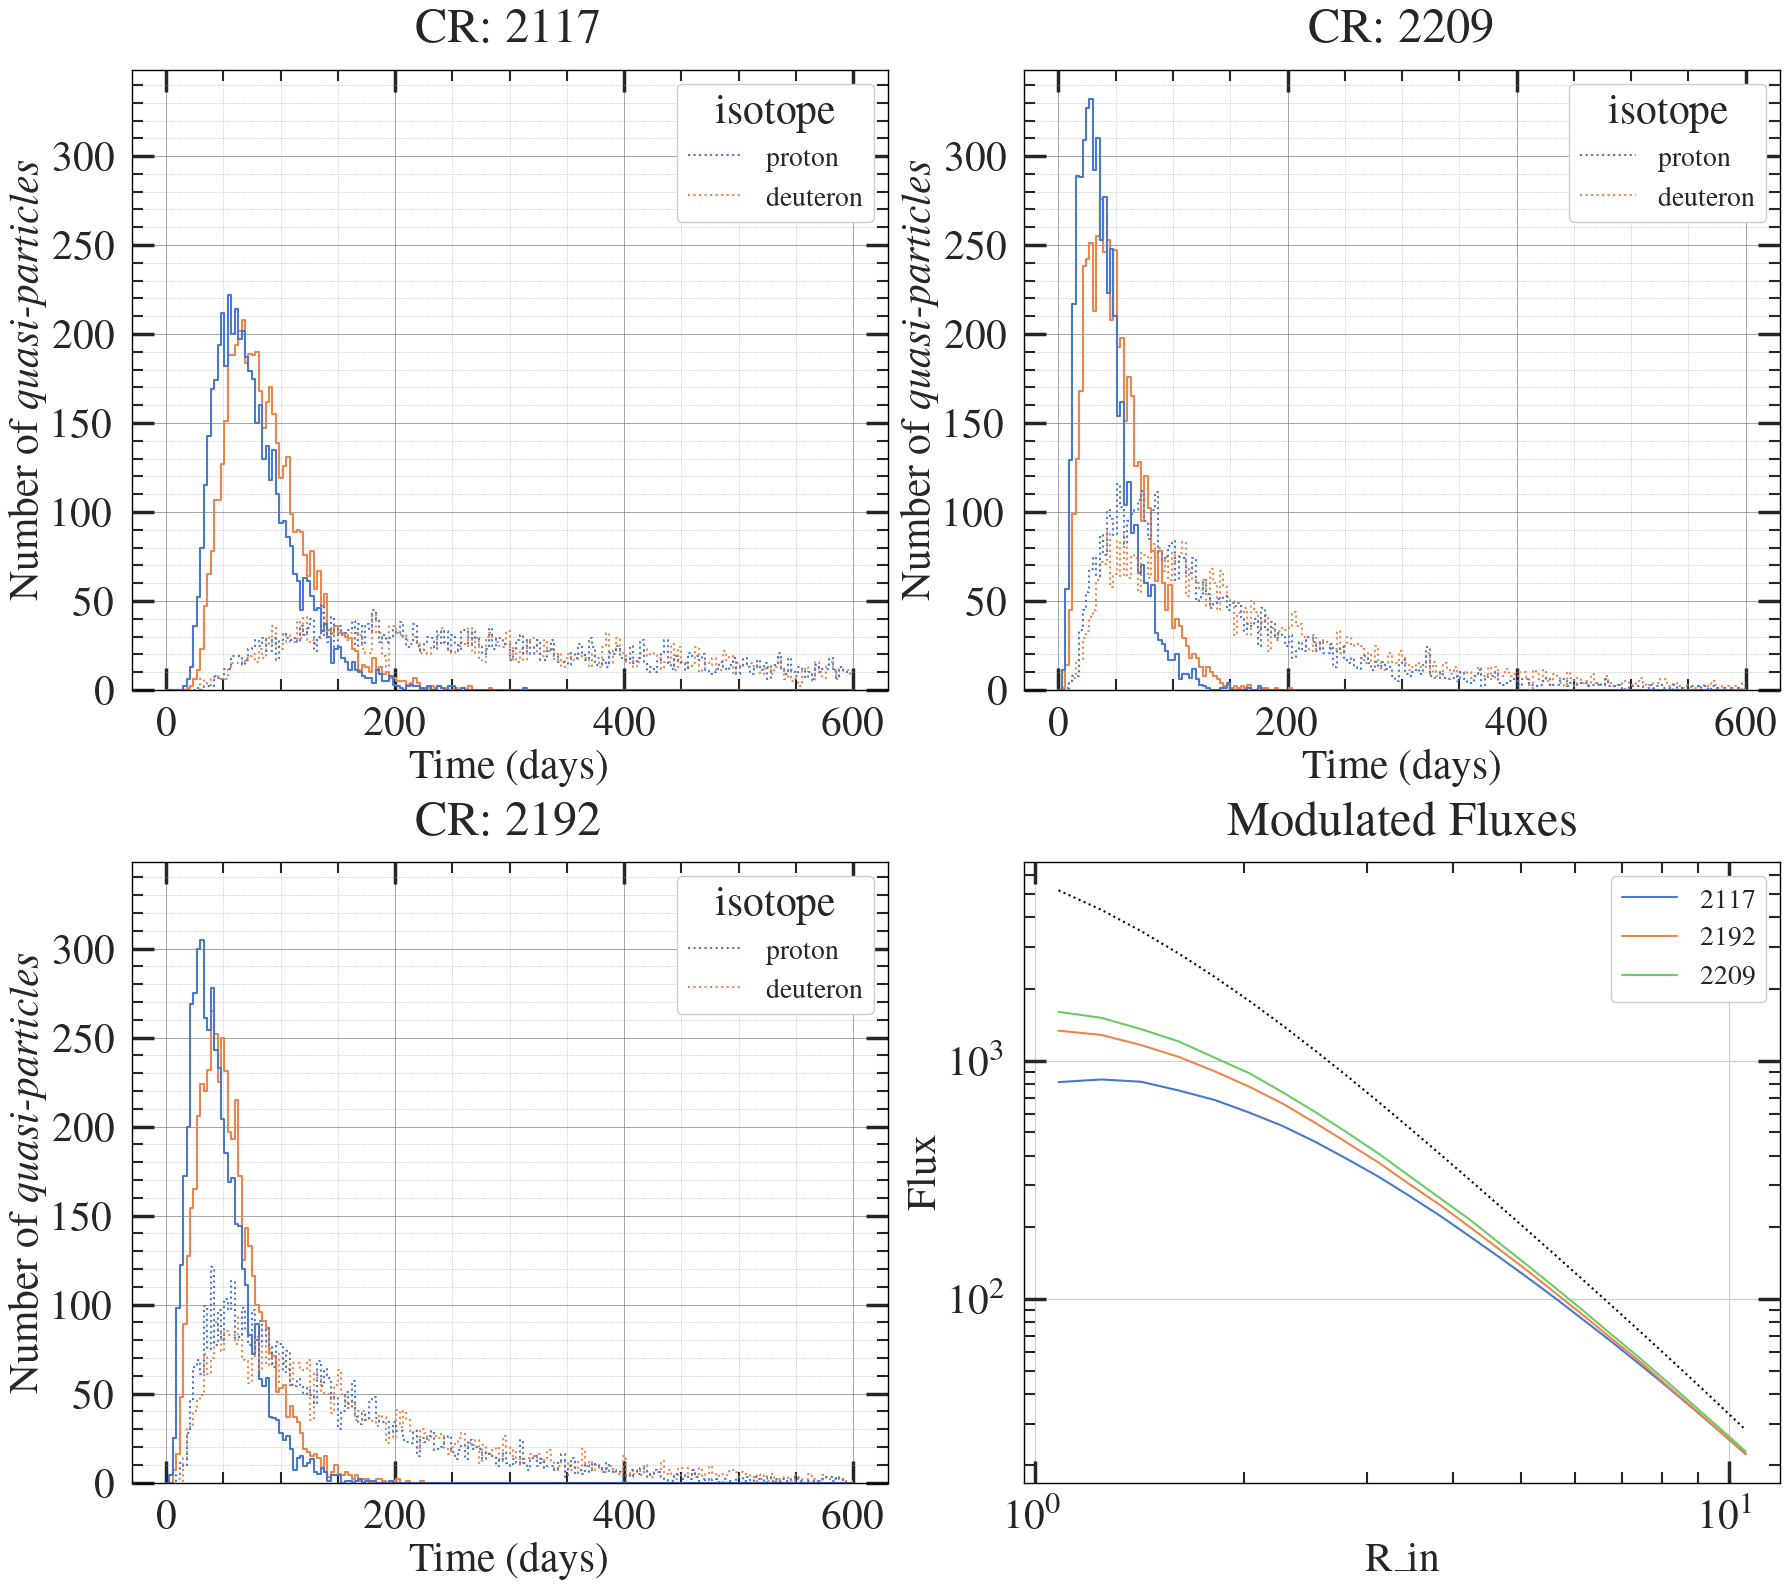

In [162]:
def plot_time_vs_count(rig, crs, isos=('proton', 'deuteron')):
    df_ = particles_df.copy().query(f'(R_in == {rig})')
    df_['zone_all'] = df_.filter(regex='zone_').sum(axis=1) / 86400
    df_['heliosheat'] /= 86400
    df_['t_fly'] /= 86400
    fig, axs = plt.subplots(2, 2, tight_layout=True, figsize=(18, 8 * 2))
    axs = axs.ravel()

    for cr, ax in zip(crs, axs):
        set_axis_fine_grid(ax)
        ax.sharex(axs[0])
        ax.sharey(axs[0])
        sns.histplot(
            df_.query(f'cr == {cr}'),
            x='zone_all',
            hue='isotope',
            element='step',
            palette='muted',
            fill=False,
            bins=200,
            binrange=(0, 600),
            linestyle='-',
            ax=ax,
        )
        sns.histplot(
            df_.query(f'cr == {cr}'),
            x='heliosheat',
            hue='isotope',
            element='step',
            palette='muted',
            fill=False,
            bins=200,
            binrange=(0, 600),
            linestyle=':',
            ax=ax,
        )
        ax.set(title=fr'CR: {cr}', xlabel='Time (days)', ylabel=r'Number of \textit{quasi-particles}')

    sns.lineplot(
        fluxes_df.query(f'(cr in {crs}) & (rig <= 11)'),
        x='rig',
        y='flux',
        hue='cr',
        palette='muted',
        ax=axs[-1],
    )
    sns.lineplot(
        fluxes_df.query(f'(cr == {crs[0]}) & (rig < 11)'),
        x='rig',
        y='lis',
        linestyle=':',
        color='k',
        ax=axs[-1],
    )
    axs[-1].set(title='Modulated Fluxes', xlabel=r'R_{in}', ylabel=r'Flux', xscale='log', yscale='log')


plot_time_vs_count(1.08, [2117, 2209, 2192])